# Homework Starter — Stage 10b: Time Series & Classification
Fill in the TODOs. Use your own project dataset or adapt the synthetic generator below.

In [20]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [21]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

## Option A: Use Your Project Data (Recommended)
Load your data here (ensure a DateTime index for time series).

In [22]:
# TODO: load your data
df = pd.read_csv('./data/api_source-alpha_symbol-AAPL_20260817-141707.csv', parse_dates=['date'], index_col='date')
df['ret'] = df['close'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()


,close,ret,log_ret
date,,,
2026-03-24,251.64,0.000000,0.000000
2026-03-25,252.62,0.003894,0.003887
2026-03-26,252.89,0.001069,0.001068
2026-03-27,248.80,-0.016173,-0.016305
2026-03-30,246.63,-0.008722,-0.008760


## Option B: Synthetic Generator (Use if you don't have data ready)

In [23]:
# Synthetic series with regimes & jumps
# n=500
# dates=pd.bdate_range('2021-01-01', periods=n)
# mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
# sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
# eps = np.random.normal(mu, sigma)
# jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
# jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
# rets = eps + jumps
# price = 100*np.exp(np.cumsum(rets))
# df = pd.DataFrame({'price':price}, index=dates)
# df['ret'] = df['price'].pct_change().fillna(0.0)
# df['log_ret'] = np.log1p(df['ret'])
# df.head()

## Feature Engineering

In [24]:
# TODO: create at least two features
df['lag_1'] = df['ret'].shift(1)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
# Add your own:
df['roll_vol_5'] = df['ret'].rolling(5).std().shift(1)
df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret']>0).astype(int)
df_feat = df.dropna().copy()
df_feat.head()

,close,ret,log_ret,lag_1,roll_mean_5,roll_vol_5,y_next_ret,y_up
date,,,,,,,,
2026-03-31,253.79,0.029031,0.028618,-0.008722,-0.003986,0.008284,0.007250,1
2026-04-01,255.63,0.007250,0.007224,0.029031,0.001820,0.017177,0.001134,1
2026-04-02,255.92,0.001134,0.001134,0.007250,0.002491,0.017343,0.011488,1
2026-04-06,258.86,0.011488,0.011422,0.001134,0.002504,0.017342,-0.020706,0
2026-04-07,253.50,-0.020706,-0.020924,0.011488,0.008036,0.013980,0.021302,1


## Split

In [25]:
# Time-aware split
cut=int(len(df_feat)*0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]
features=['lag_1','roll_mean_5','roll_vol_5']  # extend as you add features
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']
y_tr_clf, y_te_clf = train['y_up'], test['y_up']

## Pipeline + Model (Choose one track below)

In [26]:
# # Track 1: Forecasting returns
# reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
# reg.fit(X_tr, y_tr_reg)
# pred = reg.predict(X_te)
# rmse = mean_squared_error(y_te_reg, pred) ** 0.5   # `squared=False` was removed in sklearn >= 1.6
# print('RMSE:', rmse)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.53      1.00      0.69        10

    accuracy                           0.53        19
   macro avg       0.26      0.50      0.34        19
weighted avg       0.28      0.53      0.36        19



d:\Program_tools\Python\anaconda3\envs\bootcamp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Program_tools\Python\anaconda3\envs\bootcamp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Program_tools\Python\anaconda3\envs\bootcamp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

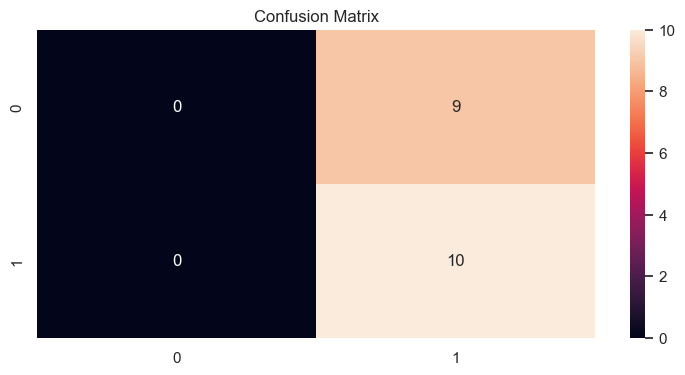

In [27]:
# Track 2: Classification (up/down)
clf = Pipeline([('scaler', StandardScaler()), ('logit', LogisticRegression(max_iter=1000))])
clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)
print(classification_report(y_te_clf, predc))
cm = confusion_matrix(y_te_clf, predc)
sns.heatmap(cm, annot=True, fmt='d'); plt.title('Confusion Matrix'); plt.show()

## Interpretation (Markdown)
- What worked?

The classification pipeline was successfully implemented using lagged return, rolling mean return, and rolling volatility as features. A time-aware train/test split was used to preserve the temporal order of the observations. The Logistic Regression model correctly identified all of the upward observations in the test set, resulting in a recall of 1.00 for class 1.
- Where might assumptions fail?

Although the model achieved an accuracy of 0.53, it failed to identify any downward observations. This indicates that the model predicted the upward class for all test observations rather than effectively distinguishing between upward and downward movements. Therefore, the accuracy alone does not indicate strong predictive performance. The relatively small test set of 19 observations also makes the evaluation sensitive to individual predictions.

- How would you extend features or model?

The feature set could be extended by adding more lagged returns, longer-window rolling statistics, momentum indicators, and trading volume features. Other classification models, such as Decision Trees or other tree-based models, could be compared with Logistic Regression. A larger dataset and time-series cross-validation could also provide a more reliable evaluation of the model's predictive performance.

### Save Notebook
Remember to save as `homework10b_modeling-time-series-and-classification_submission.ipynb`.